# Sentinel-1 Level-0 → Focused SLC (Stripmap/S6)

Bản rút gọn theo phong cách notebook gốc:

- Giữ **Doppler Centroid theo từng focusing block**
- Giữ **SRC**
- Giữ **RCMC bằng sinc interpolation**
- Giữ **azimuth focusing theo block + overlap**
- Bỏ các bước preflight / consistency check / debug table không cần thiết
- Giải phóng các mảng trung gian lớn ngay sau khi dùng
- Hiển thị ảnh giống notebook tác giả: `abs(...)`, downsample khi hiển thị và `LogNorm`

> Giả thiết: dữ liệu đầu vào và metadata đã hợp lệ, SWST/PRI/Rank/RGDEC không đổi trong acquisition chunk đã chọn.


## 1 - Imports and input file

In [1]:
import gc
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import sentinel1decoder
from precise_effective_velocity import make_estimator_from_notebook

from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq

pd.set_option("display.max_columns", None)


In [2]:
filepath = "./data/sao_paulo/"
filename = "s1a-s6-raw-s-vv-20251226t214356-20251226t214427-062491-07d496.dat"

inputfile = filepath + filename
l0file = sentinel1decoder.Level0File(inputfile)


## 2 - Metadata and acquisition chunk

In [3]:
l0file.packet_metadata


Packet Version Number  Packet Type  \
Acquisition Chunk Packet Number                                       
0                 0                                  0            0   
                  1                                  0            0   
                  2                                  0            0   
                  3                                  0            0   
                  4                                  0            0   
...                                                ...          ...   
27                50701                              0            0   
                  50702                              0            0   
                  50703                              0            0   
                  50704                              0            0   
                  50705                              0            0   

                                 Secondary Header Flag  PID  PCAT  \
Acquisition Chunk Packet Number                                     
0                 0                                  1   65    12   
                  1                                  1   65    12   
                  2                                  1   65    12   
                  3                                  1   65    12   
                  4                                  1   65    12   
...                                                ...  ...   ...   
27                50701                              1   65    12   
                  50702                              1   65    12   
                  50703                              1   65    12   
                  50704                              1   65    12   
                  50705                              1   65    12   

                                 Sequence Flags  Packet Sequence Count  \
Acquisition Chunk Packet Number                                          
0                 0                           3                      0   
                  1                           3                      1   
                  2                           3                      2   
                  3                           3                      3   
                  4                           3                      4   
...                                         ...                    ...   
27                50701                       3                   1549   
                  50702                       3                   1550   
                  50703                       3                   1551   
                  50704                       3                   1552   
                  50705                       3                   1553   

                                 Packet Data Length  Coarse Time  Fine Time  \
Acquisition Chunk Packet Number                                               
0                 0                           25086   1450820654   0.593239   
                  1                           25086   1450820654   0.593834   
                  2                           25086   1450820654   0.594444   
                  3                           25086   1450820654   0.595039   
                  4                           25086   1450820654   0.595650   
...                                             ...          ...        ...   
27                50701                       25126   1450820685   0.228447   
                  50702                       25126   1450820685   0.229057   
                  50703                       25126   1450820685   0.229652   
                  50704                       25126   1450820685   0.230247   
                  50705                       25126   1450820685   0.230858   

                                      Sync  Data Take ID  \
Acquisition Chunk Packet Number                            
0                 0              892270675     262745280   
                  1              8922706

In [4]:
l0file.ephemeris


,X-axis position ECEF,Y-axis position ECEF,Z-axis position ECEF,X-axis velocity ECEF,Y-axis velocity ECEF,Z-axis velocity ECEF,POD Solution Data Timestamp,Q0 Attitude Quaternion,Q1 Attitude Quaternion,Q2 Attitude Quaternion,Q3 Attitude Quaternion,Omega-X Angular Rate,Omega-Y Angular Rate,Omega-Z Angular Rate,Attitude Data Timestamp
0,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
1,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
2,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
3,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
4,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09
758,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09
759,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09
760,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09


In [5]:
selected_chunk = 13

selection = l0file.get_acquisition_chunk_metadata(selected_chunk)
selection


,Packet Version Number,Packet Type,Secondary Header Flag,PID,PCAT,Sequence Flags,Packet Sequence Count,Packet Data Length,Coarse Time,Fine Time,Sync,Data Take ID,ECC Number,Test Mode,Rx Channel ID,Instrument Configuration ID,Sub-commutated Ancilliary Data Word Index,Sub-commutated Ancilliary Data Word,Space Packet Count,PRI Count,Error Flag,BAQ Mode,BAQ Block Length,Range Decimation,Rx Gain,Tx Ramp Rate,Tx Pulse Start Frequency,Tx Pulse Length,Rank,PRI,SWST,SWL,SAS SSB Flag,Polarisation,Temperature Compensation,Elevation Beam Address,Azimuth Beam Address,SAS Test Mode,Cal Type,Calibration Beam Address,Calibration Mode,Tx Pulse Number,Signal Type,Swap Flag,Swath Number,Number of Quads
Packet Number,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
408,0,0,1,65,12,3,408,14514,1450820654,0.910637,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,25,48627,408,3826,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
409,0,0,1,65,12,3,409,14678,1450820654,0.911247,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,26,37203,409,3827,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
410,0,0,1,65,12,3,410,14622,1450820654,0.911842,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,27,48895,410,3828,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
411,0,0,1,65,12,3,411,14662,1450820654,0.912437,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,28,53525,411,3829,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
412,0,0,1,65,12,3,412,14606,1450820654,0.913048,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,29,48671,412,3830,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30337,0,0,1,65,12,3,13953,13098,1450820672,0.902458,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,30,65245,30337,33755,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
30338,0,0,1,65,12,3,13954,13106,1450820672,0.903069,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,31,14385,30338,33756,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
30339,0,0,1,65,12,3,13955,13114,1450820672,0.903664,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,32,46065,30339,33757,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975


## 3 - Decode raw I/Q data

In [6]:
radar_data = l0file.get_acquisition_chunk_data(selected_chunk)

len_az_line, raw_len_range_line = radar_data.shape

print("Raw data shape:", radar_data.shape)


Raw data shape: (29934, 19950)


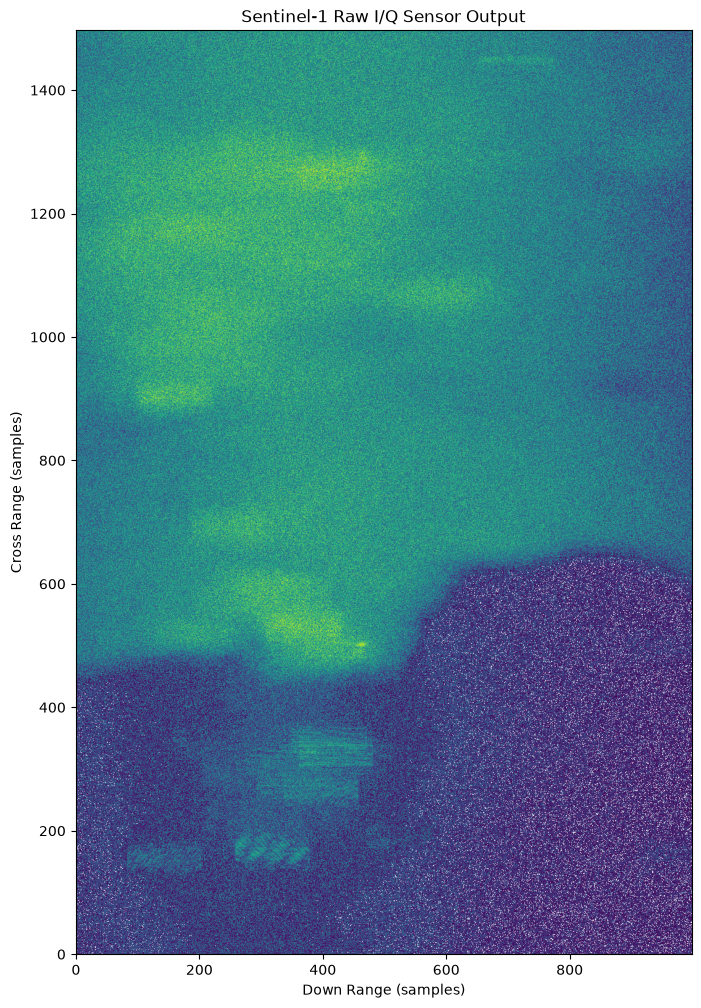

In [ ]:
# Quick-look only
plt.figure(figsize=(12, 12))
plt.title("Sentinel-1 Raw I/Q Sensor Output")
plt.imshow(
    np.abs(radar_data[::20, ::20]),
    origin="lower",
    norm=colors.LogNorm()
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


## 4 - Processing parameters and geometry

In [8]:
# Radar parameters
c = sentinel1decoder.constants.SPEED_OF_LIGHT_MPS #Tốc độ ánh sáng
wavelength_m = sentinel1decoder.constants.TX_WAVELENGTH_M 

RGDEC = selection["Range Decimation"].iloc[0] 
PRI = selection["PRI"].iloc[0]
rank = selection["Rank"].iloc[0]

TXPSF = selection["Tx Pulse Start Frequency"].iloc[0]
TXPRR = selection["Tx Ramp Rate"].iloc[0]
TXPL = selection["Tx Pulse Length"].iloc[0]

range_sample_freq = sentinel1decoder.utilities.range_dec_to_sample_rate(RGDEC)
range_sample_period = 1.0 / range_sample_freq
az_sample_freq = 1.0 / PRI
az_sample_period = PRI

suppressed_data_time = 320.0 / (8.0 * sentinel1decoder.constants.F_REF)

# Range-time axis of the decoded raw line
range_start_time = selection["SWST"].iloc[0] + suppressed_data_time
raw_fast_time_vec_s = range_start_time + np.arange(raw_len_range_line) / range_sample_freq
raw_slant_range_time_vec_s = rank * PRI + raw_fast_time_vec_s
raw_slant_range_vec_m = raw_slant_range_time_vec_s * c / 2.0

# Azimuth time of each echo packet
packet_azimuth_times_s = (
    selection["Coarse Time"].to_numpy(dtype=float)
    + selection["Fine Time"].to_numpy(dtype=float)
)

# --- PHẦN BỔ SUNG IN TẤT CẢ CÁC BIẾN ---
print("=== HẰNG SỐ & THAM SỐ RADAR HỆ THỐNG ===")
print("Speed of light (c):", c, "m/s")
print("Wavelength:", wavelength_m, "m")
print("Range Decimation (RGDEC):", RGDEC)
print("PRI:", PRI, "s")
print("Rank:", rank)
print("Tx Pulse Start Frequency (TXPSF):", TXPSF, "Hz")
print("Tx Ramp Rate (TXPRR):", TXPRR, "Hz/s")
print("Tx Pulse Length (TXPL):", TXPL, "s")

print("\n=== TẦN SỐ VÀ CHU KỲ LẤY MẪU ===")
print("Range sampling frequency:", range_sample_freq / 1e6, "MHz")
print("Range sampling period:", range_sample_period, "s")
print("PRF (Azimuth sampling frequency):", az_sample_freq, "Hz")
print("Azimuth sampling period:", az_sample_period, "s")
print("Suppressed data time:", suppressed_data_time, "s")

print("\n=== THÔNG SỐ TRỤC RANGE (KHOẢNG CÁCH) ===")
print("Raw range samples (Số lượng mẫu):", raw_len_range_line)
print("Range start time:", range_start_time, "s")

# Đối với mảng dữ liệu (vector), in kích thước và giá trị đầu/cuối để tránh tràn màn hình
print("\n=== DỮ LIỆU VECTOR (MẢNG) ===")
print(f"raw_fast_time_vec_s (Kích thước: {raw_fast_time_vec_s.shape}):")
print(f"  - Bắt đầu: {raw_fast_time_vec_s[0]} s")
print(f"  - Kết thúc: {raw_fast_time_vec_s[-1]} s")

print(f"raw_slant_range_time_vec_s (Kích thước: {raw_slant_range_time_vec_s.shape}):")
print(f"  - Bắt đầu: {raw_slant_range_time_vec_s[0]} s")
print(f"  - Kết thúc: {raw_slant_range_time_vec_s[-1]} s")

print(f"raw_slant_range_vec_m (Kích thước: {raw_slant_range_vec_m.shape}):")
print(f"  - Gần nhất (Near range): {raw_slant_range_vec_m[0] / 1000.0} km")
print(f"  - Xa nhất (Far range): {raw_slant_range_vec_m[-1] / 1000.0} km")

print(f"packet_azimuth_times_s (Kích thước: {packet_azimuth_times_s.shape}):")
print(f"  - Bắt đầu: {packet_azimuth_times_s[0]} s")
print(f"  - Kết thúc: {packet_azimuth_times_s[-1]} s")


=== HẰNG SỐ & THAM SỐ RADAR HỆ THỐNG ===
Speed of light (c): 299792458.0 m/s
Wavelength: 0.055465764662349676 m
Range Decimation (RGDEC): RGDEC 9
PRI: 0.000601150045968743 s
Rank: 10
Tx Pulse Start Frequency (TXPSF): -21094036.48895405 Hz
Tx Ramp Rate (TXPRR): 825635554407.1796 Hz/s
Tx Pulse Length (TXPL): 5.109935242723139e-05 s

=== TẦN SỐ VÀ CHU KỲ LẤY MẪU ===
Range sampling frequency: 46.9184028 MHz
Range sampling period: 2.1313598509794114e-08 s
PRF (Azimuth sampling frequency): 1663.4782059918455 Hz
Azimuth sampling period: 0.000601150045968743 s
Suppressed data time: 1.0656799254897057e-06 s

=== THÔNG SỐ TRỤC RANGE (KHOẢNG CÁCH) ===
Raw range samples (Số lượng mẫu): 19950
Range start time: 8.44018500987847e-05 s

=== DỮ LIỆU VECTOR (MẢNG) ===
raw_fast_time_vec_s (Kích thước: (19950,)):
  - Bắt đầu: 8.44018500987847e-05 s
  - Kết thúc: 0.0005095868267706675 s
raw_slant_range_time_vec_s (Kích thước: (19950,)):
  - Bắt đầu: 0.006095902309786214 s
  - Kết thúc: 0.006521087286458098

In [9]:
# Precise effective-velocity estimator.
#
# The helper sorts and de-duplicates the L0 PVT orbit epochs, then constructs
# a cubic Hermite orbit interpolator using both ECEF position and velocity.
vr_estimator = make_estimator_from_notebook(
    l0file,
    wavelength_m
)

print("Unique orbit epochs:", vr_estimator.orbit_times_s.size)
print(
    "Orbit interval:",
    vr_estimator.orbit_times_s[0],
    "to",
    vr_estimator.orbit_times_s[-1],
    "GPS seconds"
)

# Packet Coarse/Fine Time and POD Solution Data Timestamp are in the same
# GPS-time basis in sentinel1decoder. Do not mix these with UTC annotation
# timestamps without applying the GPS-UTC offset.
if (
    packet_azimuth_times_s[0] < vr_estimator.orbit_times_s[0]
    or packet_azimuth_times_s[-1] > vr_estimator.orbit_times_s[-1]
):
    raise ValueError(
        "Echo packet times are outside the available ephemeris interval."
    )

print(
    "Echo interval:",
    packet_azimuth_times_s[0],
    "to",
    packet_azimuth_times_s[-1],
    "GPS seconds"
)


Unique orbit epochs: 31
Orbit interval: 1450820654.0 to 1450820684.0 GPS seconds
Echo interval: 1450820654.910637 to 1450820672.904869 GPS seconds


### Orbit interpolation

Orbit interpolation is now encapsulated in `PreciseEffectiveVelocity`.

The old `interp1d` position/velocity interpolation and the approximate
`V_r = sqrt(V_s V_g)` geometry are intentionally removed from this notebook.


## 5 - Doppler Centroid records

In [10]:
DCE_RECORDS = [
    {
        "azimuthTime": "2025-12-26T21:43:59.100490",
        "t0": 6.095910535477454e-03,
        "dataDcPolynomial": np.array([4.152910e+01, 1.012491e+05, -4.252661e+08]),
        "fineStart": "2025-12-26T21:43:57.297041",
        "fineStop": "2025-12-26T21:44:00.903940",
    },
    {
        "azimuthTime": "2025-12-26T21:44:14.095877",
        "t0": 6.095910535477454e-03,
        "dataDcPolynomial": np.array([1.141131e+01, 1.275731e+04, 6.579813e+07]),
        "fineStart": "2025-12-26T21:44:12.292428",
        "fineStop": "2025-12-26T21:44:15.899327",
    },
    {
        "azimuthTime": "2025-12-26T21:44:25.484967",
        "t0": 6.095910535477454e-03,
        "dataDcPolynomial": np.array([3.263240e+01, -2.579159e+03, -1.314992e+08]),
        "fineStart": "2025-12-26T21:44:23.681518",
        "fineStop": "2025-12-26T21:44:27.288417",
    },
]

# DCE annotation timestamps are UTC strings, while L0 packet and POD timestamps
# used by sentinel1decoder are GPS seconds from 1980-01-06.
#
# GPS-UTC = 18 s for this 2025 acquisition.
GPS_EPOCH_UTC = np.datetime64("1980-01-06T00:00:00", "us")
GPS_UTC_OFFSET_S = 18.0


def utc_iso_to_gps_seconds(text):
    utc_seconds_from_gps_epoch = (
        np.datetime64(text, "us") - GPS_EPOCH_UTC
    ) / np.timedelta64(1, "s")

    return float(utc_seconds_from_gps_epoch + GPS_UTC_OFFSET_S)


for rec in DCE_RECORDS:
    rec["azimuth_s"] = utc_iso_to_gps_seconds(rec["azimuthTime"])
    rec["fine_start_s"] = utc_iso_to_gps_seconds(rec["fineStart"])
    rec["fine_stop_s"] = utc_iso_to_gps_seconds(rec["fineStop"])


def evaluate_dce(rec, slant_range_time_s):
    dt = slant_range_time_s - rec["t0"]
    c0, c1, c2 = rec["dataDcPolynomial"]
    return c0 + c1 * dt + c2 * dt**2


def dce_for_block(block_center_index):
    az_time = packet_azimuth_times_s[block_center_index]
    records = DCE_RECORDS

    # Hold the nearest endpoint outside the available DCE centre interval.
    if az_time <= records[0]["azimuth_s"]:
        return evaluate_dce(records[0], slant_range_time_vec_s)

    if az_time >= records[-1]["azimuth_s"]:
        return evaluate_dce(records[-1], slant_range_time_vec_s)

    # Research-processor choice: linearly interpolate polynomial coefficients
    # between adjacent DCE records. DAD does not prescribe this interpolation.
    for rec0, rec1 in zip(records[:-1], records[1:]):
        if rec0["azimuth_s"] <= az_time <= rec1["azimuth_s"]:
            alpha = (
                (az_time - rec0["azimuth_s"])
                / (rec1["azimuth_s"] - rec0["azimuth_s"])
            )

            coeff = (
                (1.0 - alpha) * rec0["dataDcPolynomial"]
                + alpha * rec1["dataDcPolynomial"]
            )

            # t0 is identical in these three DCE records.
            dt = slant_range_time_vec_s - rec0["t0"]

            return (
                coeff[0]
                + coeff[1] * dt
                + coeff[2] * dt**2
            )

    raise RuntimeError("No DCE interval found for block centre.")


print(
    "DCE centres (GPS s):",
    [rec["azimuth_s"] for rec in DCE_RECORDS]
)
print(
    "Echo packet interval (GPS s):",
    packet_azimuth_times_s[0],
    packet_azimuth_times_s[-1]
)


DCE centres (GPS s): [1450820657.10049, 1450820672.095877, 1450820683.484967]
Echo packet interval (GPS s): 1450820654.910637 1450820672.904869


## 6 - Range compression

In [11]:
# Build the transmitted chirp replica.
#
# Space Packet Protocol Sec. 3.2.5.8 defines the number of complex Tx-pulse
# samples after decimation as ceil(TXPL * f_dec).
num_tx_vals = int(np.ceil(TXPL * range_sample_freq))
print("Tx replica samples:", num_tx_vals)

tx_time = (
    np.arange(num_tx_vals) / range_sample_freq
    - (num_tx_vals - 1) / (2.0 * range_sample_freq)
)

phi1 = TXPSF + TXPRR * TXPL / 2.0
phi2 = TXPRR / 2.0

tx_replica = np.exp(
    2.0j * np.pi * (phi1 * tx_time + phi2 * tx_time**2)
).astype(np.complex64)


Tx replica samples: 2398


In [12]:

# Linear matched filter.
range_mf = np.conjugate(tx_replica[::-1]).astype(np.complex64)
range_mf /= np.sqrt(np.sum(np.abs(range_mf)**2))

linear_conv_len = raw_len_range_line + num_tx_vals - 1
range_fft_size = 1 << int(np.ceil(np.log2(linear_conv_len)))
range_filter_fft = fft(range_mf, n=range_fft_size).astype(np.complex64)


In [13]:

# Keep only the valid matched-filter support.
same_start = (num_tx_vals - 1) // 2
throw_left = (num_tx_vals - 1) // 2
throw_right = (num_tx_vals - 1) - throw_left

valid_start = throw_left
valid_stop = raw_len_range_line - throw_right
len_range_line = valid_stop - valid_start

range_compressed = np.empty(
    (len_az_line, len_range_line),
    dtype=np.complex64
)
print(valid_start, valid_stop)


1198 18751


In [14]:

# Process several azimuth lines at a time to limit peak RAM.
RANGE_CHUNK = 256

for a0 in range(0, len_az_line, RANGE_CHUNK):
    a1 = min(a0 + RANGE_CHUNK, len_az_line)

    X = fft(radar_data[a0:a1], n=range_fft_size, axis=1)
    y = ifft(X * range_filter_fft[None, :], axis=1)
    y = y[:, same_start:same_start + raw_len_range_line]

    range_compressed[a0:a1] = y[:, valid_start:valid_stop]

# Range axis now follows the valid range-compressed samples.
slant_range_time_vec_s = raw_slant_range_time_vec_s[valid_start:valid_stop]
slant_range_vec_m = slant_range_time_vec_s * c / 2.0

del radar_data, X, y
del tx_time, tx_replica, range_mf, range_filter_fft
del raw_fast_time_vec_s, raw_slant_range_time_vec_s, raw_slant_range_vec_m
gc.collect()

print("Range-compressed shape:", range_compressed.shape)


Range-compressed shape: (29934, 17553)


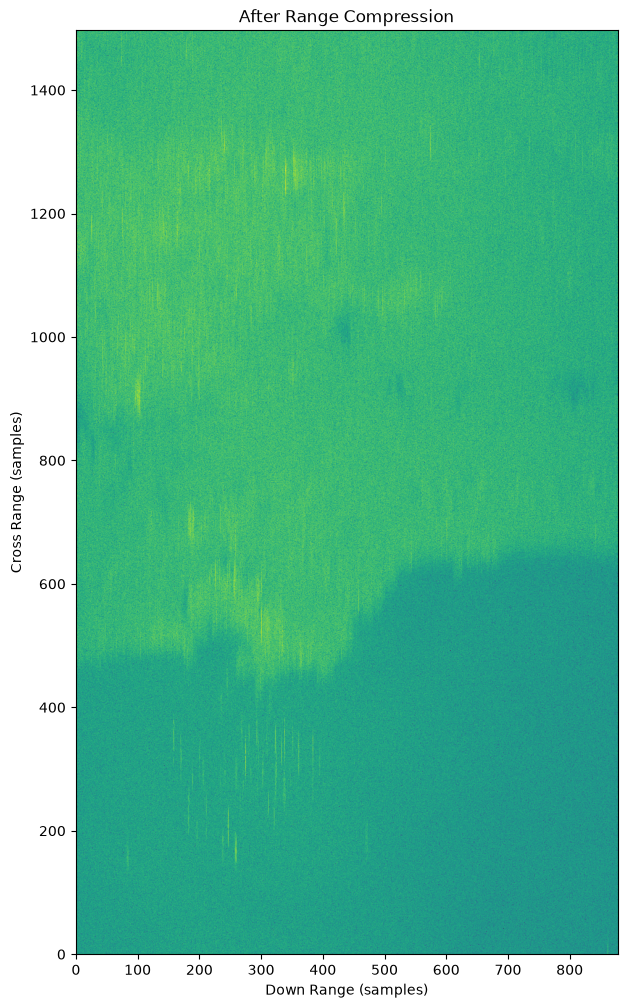

In [15]:
# Quick-look after range compression.
plt.figure(figsize=(12, 12))
plt.title("After Range Compression")
plt.imshow(
    np.abs(range_compressed[::20, ::20]),
    origin="lower",
    norm=colors.LogNorm()
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


## 7 - Focusing configuration

In [16]:
# Sentinel-1 Stripmap azimuth focusing parameters
# ESA DAD Sec. 9.10-9.13 + AUX_PP1, productId = SM_SL1__1, swath = S6.
#
# AUX_PP1:
#   aziProcBandwidth         = 1398 Hz
#   aziBlockSize             = 4096
#   extraAziProcBlockOverlap = 50 samples
#   maxFdc                   = 100 Hz
#
# DAD 9.12 states that the maximum matched-filter support A and DeltaOv are
# ultimately beam-dependent configurable parameters, unique for all scenes.
# The supplied AUX_PP1 exposes DeltaOv=50 but not A. Therefore this research
# processor estimates A once from representative scene geometry and then keeps
# one fixed overlap for all focusing blocks.

AZIMUTH_PROCESSING_BANDWIDTH_HZ = 1398.0
FOCUS_FFT_LEN = 4096
EXTRA_AZIMUTH_PROCESSING_BLOCK_OVERLAP = 50
MAX_FDC_HZ = 100.0

SRC_SEGMENT_SAMPLES = 1024
RCMC_KERNEL_LENGTH = 16
RCMC_NUM_PHASES = 64

# Cache V_r vectors because the Wong-style numerical fit is relatively costly.
_VR_CACHE = {}


def effective_velocity(block_center_index):
    block_center_index = int(block_center_index)

    if block_center_index not in _VR_CACHE:
        _VR_CACHE[block_center_index] = vr_estimator.evaluate_block(
            block_center_time_s=packet_azimuth_times_s[block_center_index],
            slant_range_m=slant_range_vec_m,
            fdc_hz=dce_for_block(block_center_index),
            azimuth_bandwidth_hz=AZIMUTH_PROCESSING_BANDWIDTH_HZ,
            n_control_points=9,
            range_polynomial_degree=2,
        )

    return _VR_CACHE[block_center_index]


def azimuth_fm_rate_magnitude(R0_m, Vr_mps, fdc_hz):
    # Magnitude of DAD Eq. 9-22.
    D0_sq = 1.0 - (
        wavelength_m * fdc_hz / (2.0 * Vr_mps)
    )**2

    D0 = np.sqrt(np.maximum(D0_sq, 0.0))

    return (
        2.0 * Vr_mps**2 * D0**3
        / (wavelength_m * R0_m)
    )


# Estimate the beam-wide configured A using representative azimuth positions.
# DAD notes that k_a varies only slightly around the orbit; five probes are
# enough here to avoid hundreds of nonlinear hyperbolic fits.
support_probe_indices = np.unique(
    np.round(
        np.linspace(0, len_az_line - 1, 5)
    ).astype(np.int64)
)

matched_filter_supports = []

for idx in support_probe_indices:
    Vr_probe = effective_velocity(idx)
    fdc_probe = dce_for_block(idx)

    ka_far_abs = azimuth_fm_rate_magnitude(
        slant_range_vec_m[-1],
        Vr_probe[-1],
        fdc_probe[-1]
    )

    if not np.isfinite(ka_far_abs) or ka_far_abs <= 0.0:
        raise ValueError("Invalid far-range azimuth FM rate.")

    A_probe = int(
        np.ceil(
            AZIMUTH_PROCESSING_BANDWIDTH_HZ
            / ka_far_abs
            * az_sample_freq
        )
    )

    matched_filter_supports.append(A_probe)

MATCHED_FILTER_SUPPORT_SAMPLES = int(
    np.max(matched_filter_supports)
)

# DAD Eq. 9-27: Ov = A + DeltaOv
FOCUS_OVERLAP_SAMPLES = (
    MATCHED_FILTER_SUPPORT_SAMPLES
    + EXTRA_AZIMUTH_PROCESSING_BLOCK_OVERLAP
)

FOCUS_STEP = FOCUS_FFT_LEN - FOCUS_OVERLAP_SAMPLES

if FOCUS_OVERLAP_SAMPLES >= FOCUS_FFT_LEN:
    raise ValueError(
        "Azimuth overlap must be smaller than FOCUS_FFT_LEN."
    )

print("DAD/AUX Stripmap focusing configuration")
print("Azimuth processing bandwidth:", AZIMUTH_PROCESSING_BANDWIDTH_HZ, "Hz")
print("Azimuth block / FFT length:", FOCUS_FFT_LEN, "samples")
print("Support probes:", support_probe_indices.tolist())
print("A probes:", matched_filter_supports)
print("Configured/estimated A:", MATCHED_FILTER_SUPPORT_SAMPLES, "samples")
print(
    "Extra overlap DeltaOv (AUX_PP1):",
    EXTRA_AZIMUTH_PROCESSING_BLOCK_OVERLAP,
    "samples"
)
print("Total focus overlap Ov:", FOCUS_OVERLAP_SAMPLES, "samples")
print("Focus step:", FOCUS_STEP, "samples")
print("AUX maxFdc:", MAX_FDC_HZ, "Hz (diagnostic only)")

del support_probe_indices, matched_filter_supports


DAD/AUX Stripmap focusing configuration
Azimuth processing bandwidth: 1398.0 Hz
Azimuth block / FFT length: 4096 samples
Support probes: [0, 7483, 14966, 22450, 29933]
A probes: [1203, 1210, 1212, 1210, 1212]
Configured/estimated A: 1212 samples
Extra overlap DeltaOv (AUX_PP1): 50 samples
Total focus overlap Ov: 1262 samples
Focus step: 2834 samples
AUX maxFdc: 100.0 Hz (diagnostic only)


## 8 - Secondary Range Compression (SRC)

In [17]:
def apply_src(rd, f_baseband_hz, fdc_hz, Vr_mps):
    n_az, n_rg = rd.shape
    f0_hz = c / wavelength_m

    for r0 in range(0, n_rg, SRC_SEGMENT_SAMPLES):
        r1 = min(r0 + SRC_SEGMENT_SAMPLES, n_rg)
        nseg = r1 - r0

        nfft_r = 1 << int(np.ceil(np.log2(2 * nseg)))

        seg_fft = fft(rd[:, r0:r1], n=nfft_r, axis=1)
        f_tau = fftfreq(nfft_r, d=range_sample_period)[None, :]

        rm = (r0 + r1 - 1) // 2
        Rm = slant_range_vec_m[rm]
        Vrm = Vr_mps[rm]
        fdcm = fdc_hz[rm]

        f_eta = f_baseband_hz + fdcm
        D_sq = 1.0 - (
            wavelength_m * f_eta / (2.0 * Vrm)
        )**2
        D = np.sqrt(np.maximum(D_sq, 0.0))

        Ksrc = np.full_like(f_eta, np.inf)
        nz = np.abs(f_eta) > 1e-12
        Ksrc[nz] = (
            2.0 * Vrm**2 * f0_hz**3 * D[nz]**2
            / (c * Rm * f_eta[nz]**2)
        )

        inv_Ksrc = np.zeros_like(Ksrc)
        inv_Ksrc[nz] = 1.0 / Ksrc[nz]

        Hsrc = np.exp(
            -1.0j * np.pi * f_tau**2 * inv_Ksrc[:, None]
        )

        rd[:, r0:r1] = ifft(
            seg_fft * Hsrc,
            axis=1
        )[:, :nseg]

    return rd


## 9 - Sinc RCMC

In [18]:
def build_sinc_table(length=16, phases=64):
    left = length // 2 - 1
    offsets = np.arange(-left, length - left)

    window = np.hanning(length)
    table = np.empty((phases, length))

    for p in range(phases):
        frac = p / phases
        h = np.sinc(offsets - frac) * window
        table[p] = h / np.sum(h)

    return offsets, table


RCMC_OFFSETS, RCMC_TABLE = build_sinc_table(
    RCMC_KERNEL_LENGTH,
    RCMC_NUM_PHASES
)


def apply_rcmc(rd, f_baseband_hz, fdc_hz, Vr_mps):
    n_az, n_rg = rd.shape
    out = np.zeros_like(rd)

    dR = c / (2.0 * range_sample_freq)
    R_start = slant_range_vec_m[0]

    for ia in range(n_az):
        f_eta = f_baseband_hz[ia] + fdc_hz

        D_sq = 1.0 - (
            wavelength_m * f_eta / (2.0 * Vr_mps)
        )**2
        D = np.sqrt(np.maximum(D_sq, 1e-15))

        Rsrc = slant_range_vec_m / D
        src_pos = (Rsrc - R_start) / dR

        base = np.floor(src_pos).astype(np.int64)
        frac = src_pos - base

        phase = np.floor(
            frac * RCMC_NUM_PHASES + 0.5
        ).astype(np.int64)

        carry = phase == RCMC_NUM_PHASES
        base[carry] += 1
        phase[carry] = 0

        min_idx = base + RCMC_OFFSETS[0]
        max_idx = base + RCMC_OFFSETS[-1]

        valid = (min_idx >= 0) & (max_idx < n_rg)
        cols = np.nonzero(valid)[0]

        idx = base[cols, None] + RCMC_OFFSETS[None, :]
        w = RCMC_TABLE[phase[cols]]

        out[ia, cols] = np.sum(
            rd[ia, idx] * w,
            axis=1
        )

    return out


## 10 - Azimuth focusing of one block

In [19]:
def focus_block(block, global_start, real_len):
    block_center = global_start + (real_len - 1) // 2

    fdc_hz = dce_for_block(block_center)
    Vr_mps = effective_velocity(block_center)

    f_baseband_hz = fftshift(
        fftfreq(FOCUS_FFT_LEN, d=az_sample_period)
    )

    # Range-Doppler domain
    rd = fftshift(
        fft(block, axis=0),
        axes=0
    ).astype(np.complex64)

    # Secondary Range Compression
    rd = apply_src(
        rd,
        f_baseband_hz,
        fdc_hz,
        Vr_mps
    )

    # Range Cell Migration Correction
    rd_rcmc = apply_rcmc(
        rd,
        f_baseband_hz,
        fdc_hz,
        Vr_mps
    )

    del rd
    gc.collect()

    # Azimuth matched filter, processed in range chunks to limit RAM.
    AZ_RANGE_CHUNK = 256

    for r0 in range(0, len_range_line, AZ_RANGE_CHUNK):
        r1 = min(r0 + AZ_RANGE_CHUNK, len_range_line)

        f_eta = (
            f_baseband_hz[:, None]
            + fdc_hz[None, r0:r1]
        )

        D_sq = (
            1.0
            - (
                wavelength_m
                * f_eta
                / (2.0 * Vr_mps[None, r0:r1])
            )**2
        )
        D = np.sqrt(np.maximum(D_sq, 0.0))

        Haz = np.exp(
            4.0j
            * np.pi
            * slant_range_vec_m[None, r0:r1]
            * D
            / wavelength_m
        )

        rd_rcmc[:, r0:r1] *= Haz

    focused = ifft(
        ifftshift(rd_rcmc, axes=0),
        axis=0
    ).astype(np.complex64)

    del rd_rcmc
    gc.collect()

    return focused


In [20]:
# Quick diagnostic of the new precise V_r model at the scene centre.
_vr_test_index = len_az_line // 2
_vr_test = vr_estimator.evaluate_block(
    block_center_time_s=packet_azimuth_times_s[_vr_test_index],
    slant_range_m=slant_range_vec_m,
    fdc_hz=dce_for_block(_vr_test_index),
    azimuth_bandwidth_hz=AZIMUTH_PROCESSING_BANDWIDTH_HZ,
    n_control_points=9,
    range_polynomial_degree=2,
    return_diagnostics=True,
)

print(
    "V_r near/mid/far [m/s]:",
    _vr_test.vr_mps[0],
    _vr_test.vr_mps[len_range_line // 2],
    _vr_test.vr_mps[-1],
)
print(
    "Hyperbolic fit RMS range [m], max over control points:",
    max(p.fit_rms_m for p in _vr_test.control_points)
)

# Reuse this result if the same centre index is requested later.
_VR_CACHE[_vr_test_index] = _vr_test.vr_mps
del _vr_test


V_r near/mid/far [m/s]: 7202.557628416208 7201.769180700679 7200.88648848409
Hyperbolic fit RMS range [m], max over control points: 0.0005815043542565907


## 11 - Focus all azimuth blocks and stitch

In [21]:
left_throw = FOCUS_OVERLAP_SAMPLES // 2
right_throw = FOCUS_OVERLAP_SAMPLES - left_throw

focused_image = np.zeros_like(
    range_compressed,
    dtype=np.complex64
)

for start in range(0, len_az_line, FOCUS_STEP):
    real_len = min(
        FOCUS_FFT_LEN,
        len_az_line - start
    )

    block = np.zeros(
        (FOCUS_FFT_LEN, len_range_line),
        dtype=np.complex64
    )

    block[:real_len] = range_compressed[
        start:start + real_len
    ]

    focused_block = focus_block(
        block,
        start,
        real_len
    )

    first_block = start == 0
    last_block = start + real_len >= len_az_line

    keep0 = 0 if first_block else left_throw
    keep1 = real_len if last_block else FOCUS_FFT_LEN - right_throw

    focused_image[
        start + keep0:start + keep1
    ] = focused_block[
        keep0:keep1
    ]

    del block, focused_block
    gc.collect()

    if last_block:
        break

# Range-compressed input is no longer needed.
del range_compressed
gc.collect()

print("Focused image shape:", focused_image.shape)


Focused image shape: (29934, 17553)


## 12 - Display focused image

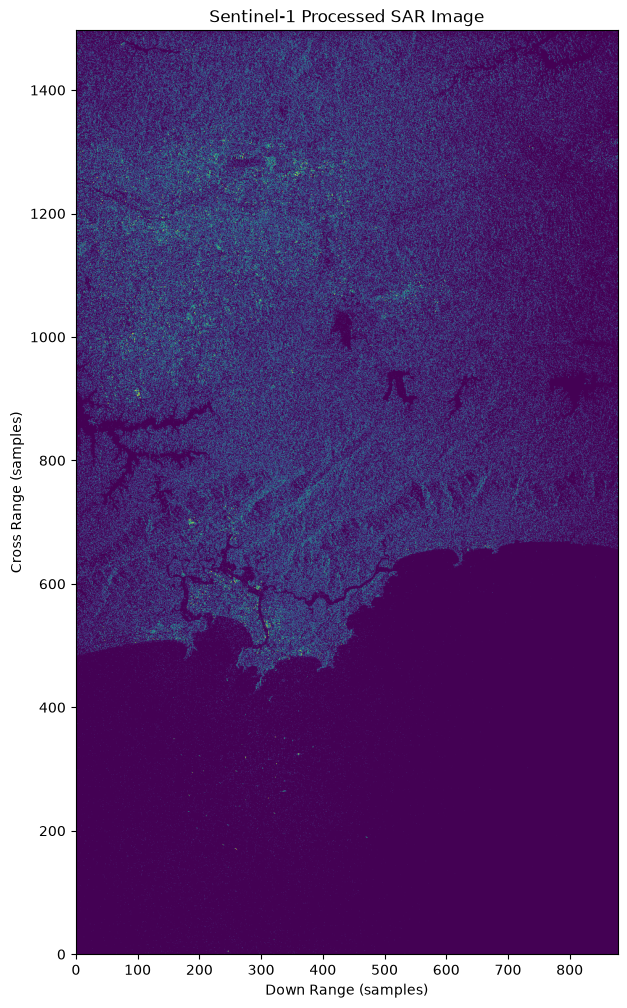

In [22]:
# Same display strategy as the author's notebook:
# use amplitude directly and decimate only for plotting.
plt.figure(figsize=(12, 12))
plt.title("Sentinel-1 Processed SAR Image")
plt.imshow(
    np.abs(focused_image[::20, ::20]),
    origin="lower",
    norm=colors.LogNorm(
        vmin=300 / np.sqrt(num_tx_vals),
        vmax=10000 / np.sqrt(num_tx_vals),
    )
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


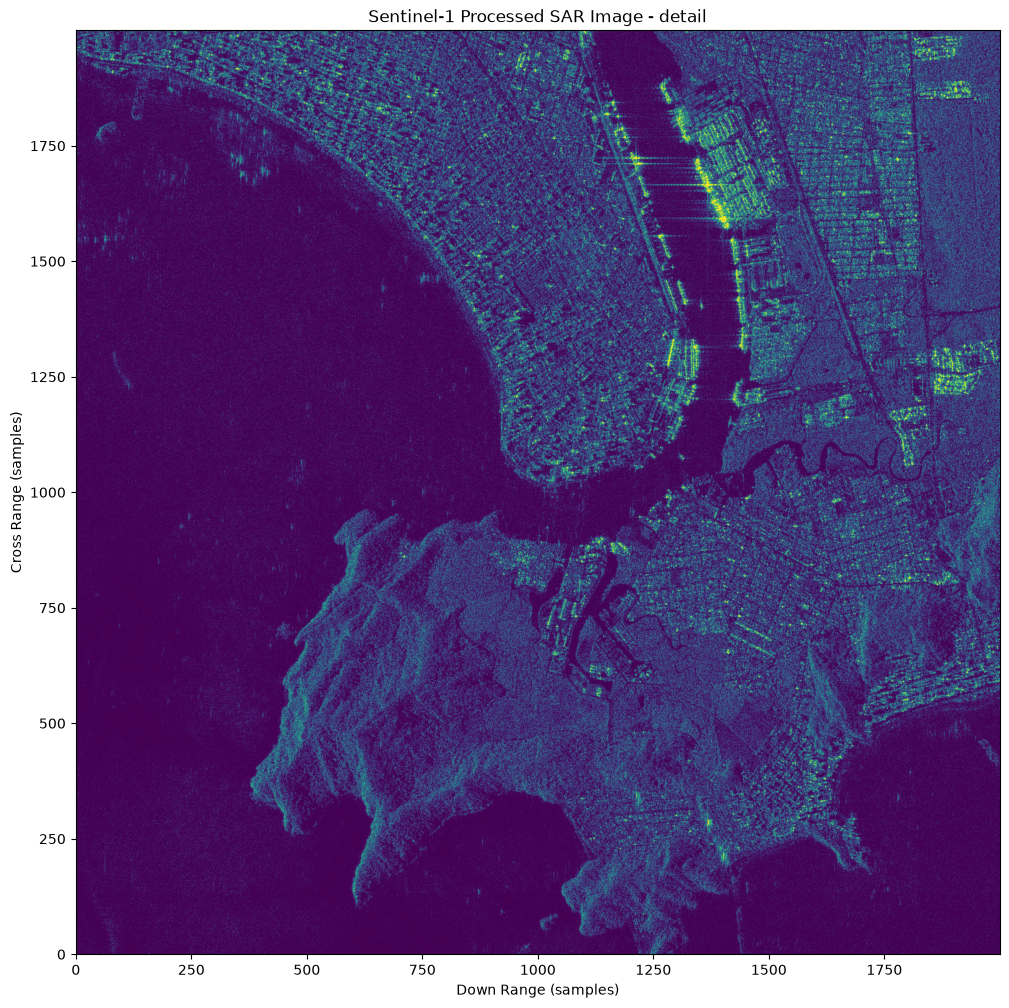

In [23]:
# Match Demo's raw-range window after valid_start samples were cropped.
plt.figure(figsize=(12, 12))
plt.title("Sentinel-1 Processed SAR Image - detail")
plt.imshow(
    np.abs(focused_image[9000:11000, 6000-valid_start:8000-valid_start]),
    origin="lower",
    norm=colors.LogNorm(
        vmin=300 / np.sqrt(num_tx_vals),
        vmax=10000 / np.sqrt(num_tx_vals),
    )
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


## 13 - Export amplitude TIFF for SNAP comparison

In [24]:
# %pip install -q tifffile

# import tifffile

# tiff_path = "simple_focused_amplitude_raw_grid.tif"
# tiff = tifffile.memmap(
#     tiff_path,
#     shape=(len_az_line, raw_len_range_line),
#     dtype=np.float32,
#     bigtiff=True,
#     photometric="minisblack",
# )

# tiff[:, :valid_start] = np.nan
# tiff[:, valid_stop:] = np.nan
# for a0 in range(0, len_az_line, RANGE_CHUNK):
#     a1 = min(a0 + RANGE_CHUNK, len_az_line)
#     tiff[a0:a1, valid_start:valid_stop] = np.abs(focused_image[a0:a1])

# tiff.flush()
# del tiff
# print("Saved for SNAP:", tiff_path)
